# Induced Seismicity Analysis (New Data)

Analysis notebook for newly added induced seismicity datasets:

- Prefer registered catalogs: `<DATASET>-Standard` / `<DATASET>`
- If not registered but `processed/*_summary.json` exists, automatically fall back to `InducedTripletBase`
- Supports both single-dataset analysis and multi-dataset batch comparison

## 1) Setup

In [1]:
from __future__ import annotations

import inspect
import sys
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import find_peaks, peak_widths


def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, cwd.parent):
        if (candidate / 'src').exists() and (candidate / 'data').exists():
            return candidate
    raise FileNotFoundError("Cannot find project root containing both 'src' and 'data'.")


PROJECT_ROOT = resolve_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import src
import src.data.catalog as catalog
import src.catalogs as catalogs
from src.catalogs.induced_triplet_base import InducedTripletBase

pd.options.display.max_columns = 120
print(f'PROJECT_ROOT: {PROJECT_ROOT}')

PROJECT_ROOT: /root/autodl-tmp/em_eqf


## 2) Dataset Discovery

In [2]:
def discover_processed_triplet_datasets(data_root: Path) -> list[str]:
    datasets: list[str] = []
    for d in sorted(data_root.iterdir()):
        if not d.is_dir():
            continue
        name = d.name
        summary_path = d / 'processed' / f'{name}_summary.json'
        eq_path = d / 'processed' / f'{name}_eq_processed.csv'
        if summary_path.exists() and eq_path.exists():
            datasets.append(name)
    return datasets


processed_datasets = discover_processed_triplet_datasets(PROJECT_ROOT / 'data')
registered_standard = sorted([x for x in catalog.Catalog.list_available() if x.endswith('-Standard')])

print(f'Discovered processed triplet datasets ({len(processed_datasets)}):')
print(processed_datasets)
print(f"Registered '*-Standard' catalogs ({len(registered_standard)}):")
print(registered_standard)

Discovered processed triplet datasets (12):
['Basel', 'CB_HAB1a', 'CB_HAB1b', 'CB_HAB4', 'FORGE2022', 'SSFS1993', 'SSFS2000', 'SSFS2003', 'SSFS2004', 'SSFS2005', 'St1-2018', 'St1-2020']
Registered '*-Standard' catalogs (25):
['AZDX-Standard', 'CB_HAB1a-Standard', 'CB_HAB1b-Standard', 'CB_HAB4-Standard', 'ChinaArray-Standard', 'ChuanDian-Standard', 'CooperBasin-Standard', 'FORGE2022-Standard', 'Geysers-Standard', 'Hauksson-Standard', 'PNR-Standard', 'PNR_1z-Standard', 'PNR_2-Standard', 'QTMSaltonSea-Standard', 'QTMSanJacinto-Standard', 'SCEDC-Standard', 'SSFS-Standard', 'SSFS1993-Standard', 'SSFS2000-Standard', 'SSFS2003-Standard', 'SSFS2004-Standard', 'SSFS2005-Standard', 'St1-2018-Standard', 'St1-2020-Standard', 'White-Standard']


## 3) Flexible Catalog Loader

In [3]:
def _pick_root_and_data_dir(dataset: str) -> tuple[Path, Path]:
    data_root = PROJECT_ROOT / 'data'
    dataset_dir = data_root / dataset
    if dataset_dir.exists():
        return dataset_dir / 'catalogs', dataset_dir
    return data_root / dataset / 'catalogs', data_root


def _filter_kwargs_for_callable(callable_obj: Any, kwargs: dict[str, Any]) -> dict[str, Any]:
    sig = inspect.signature(callable_obj)
    return {k: v for k, v in kwargs.items() if k in sig.parameters}


def load_catalog_flexible(dataset: str, catalog_cfg: dict[str, Any] | None = None):
    cfg = dict(catalog_cfg or {})
    root_dir, data_dir = _pick_root_and_data_dir(dataset)
    candidates = [f'{dataset}-Standard', dataset]

    for name in candidates:
        try:
            cls = catalog.Catalog.by_name(name)
        except RuntimeError:
            continue

        merged_kwargs = {'root_dir': str(root_dir), 'data_dir': str(data_dir), **cfg}
        init_kwargs = _filter_kwargs_for_callable(cls.__init__, merged_kwargs)
        ignored = sorted(set(merged_kwargs) - set(init_kwargs))
        if ignored:
            print(f'[{name}] ignored unsupported config keys: {ignored}')

        ds = cls(**init_kwargs)
        print(f'Using registered catalog: {name}')
        return ds

    dataset_dir = PROJECT_ROOT / 'data' / dataset
    summary_path = dataset_dir / 'processed' / f'{dataset}_summary.json'
    if not summary_path.exists():
        raise RuntimeError(
            f"No registered catalog found for {dataset!r} and fallback summary missing:\n"
            f"  {summary_path}\n"
            'Make sure preprocessing is done or add a catalog registration.'
        )

    merged_kwargs = {
        'dataset_name': dataset,
        'root_dir': str(dataset_dir / 'catalogs'),
        'data_dir': str(dataset_dir),
        **cfg,
    }
    init_kwargs = _filter_kwargs_for_callable(InducedTripletBase.__init__, merged_kwargs)
    ignored = sorted(set(merged_kwargs) - set(init_kwargs))
    if ignored:
        print(f'[InducedTripletBase fallback] ignored unsupported config keys: {ignored}')

    ds = InducedTripletBase(**init_kwargs)
    print(f'Using fallback catalog class: InducedTripletBase({dataset})')
    return ds

## 4) Series / Peak / Plot Helpers

In [4]:
def extract_injection_count_series(seq) -> dict[str, np.ndarray]:
    if 'time_series' not in seq or 'time_series_times' not in seq:
        raise ValueError('Selected sequence has no time_series/time_series_times.')

    injection = seq.time_series.squeeze().detach().cpu().numpy()
    inj_time = seq.time_series_times.squeeze().detach().cpu().numpy()
    arrival_times = seq.arrival_times.detach().cpu().numpy()

    injection = np.asarray(injection).reshape(-1)
    inj_time = np.asarray(inj_time).reshape(-1)
    arrival_times = np.asarray(arrival_times).reshape(-1)

    if inj_time.shape[0] < 2:
        raise ValueError('time_series_times must contain at least 2 samples.')
    if injection.shape[0] != inj_time.shape[0]:
        raise ValueError(
            'time_series and time_series_times must have same length, got '
            f'{injection.shape[0]} vs {inj_time.shape[0]}'
        )

    bin_counts, _ = np.histogram(arrival_times, bins=inj_time)
    injection_mid = 0.5 * (injection[1:] + injection[:-1])
    inj_time_mid = 0.5 * (inj_time[1:] + inj_time[:-1])

    return {
        'injection': injection,
        'inj_time': inj_time,
        'injection_mid': injection_mid,
        'inj_time_mid': inj_time_mid,
        'arrival_times': arrival_times,
        'bin_counts': bin_counts,
    }


def detect_peaks(
    injection_mid: np.ndarray,
    peak_height: float = 0.5,
    peak_min_distance: int = 60,
) -> dict[str, np.ndarray]:
    peaks_idx, props = find_peaks(
        injection_mid,
        height=peak_height,
        distance=peak_min_distance,
    )

    widths, width_heights, left_bases_float, right_bases_float = peak_widths(
        x=injection_mid,
        peaks=peaks_idx,
        rel_height=1,
    )

    left_bases = np.round(left_bases_float).astype(int)
    right_bases = np.round(right_bases_float).astype(int)

    return {
        'peaks_idx': peaks_idx,
        'peak_heights': props.get('peak_heights', np.array([])),
        'widths': widths,
        'width_heights': width_heights,
        'left_bases': left_bases,
        'right_bases': right_bases,
    }


def plot_global_overlay(dataset: str, series: dict[str, np.ndarray]) -> None:
    x = series['inj_time_mid']
    injection_mid = series['injection_mid']
    bin_counts = series['bin_counts']

    fig, ax1 = plt.subplots(figsize=(12, 4))
    l1 = ax1.plot(x, injection_mid, color='tab:blue', linewidth=0.8, label='Injection Rate')
    ax1.set_xlabel('Time (catalog index)')
    ax1.set_ylabel('Injection Rate', color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    ax1.grid(alpha=0.3)

    ax2 = ax1.twinx()
    l2 = ax2.plot(x, bin_counts, color='tab:orange', linewidth=0.8, label='Event Count')
    ax2.set_ylabel('Event Count', color='tab:orange')
    ax2.tick_params(axis='y', labelcolor='tab:orange')

    lines = l1 + l2
    labels = [line.get_label() for line in lines]
    ax1.legend(lines, labels, loc='upper right')
    fig.suptitle(f'{dataset}: Injection vs Event Count')
    fig.tight_layout()
    plt.show()


def plot_peak_window(
    dataset: str,
    series: dict[str, np.ndarray],
    peaks: dict[str, np.ndarray],
    peak_rank: int = 0,
    offset: int = 50,
) -> None:
    peaks_idx = peaks['peaks_idx']
    left = peaks['left_bases']
    right = peaks['right_bases']

    if len(peaks_idx) == 0:
        print(f'{dataset}: no peaks found with current thresholds.')
        return
    if peak_rank < 0 or peak_rank >= len(peaks_idx):
        raise IndexError(f'peak_rank={peak_rank} out of range [0, {len(peaks_idx)-1}]')

    x = series['inj_time_mid']
    injection_mid = series['injection_mid']
    bin_counts = series['bin_counts']

    lb = int(left[peak_rank])
    rb = int(right[peak_rank])
    start = max(0, lb - offset)
    end = min(len(injection_mid), rb + offset)

    fig, ax1 = plt.subplots(figsize=(12, 4))
    l1 = ax1.plot(x[start:end], injection_mid[start:end], color='tab:blue', label='Injection Rate', linewidth=0.8)
    ax1.set_xlabel('Time (catalog index)')
    ax1.set_ylabel('Injection Rate', color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    ax1.grid(alpha=0.3)

    ax2 = ax1.twinx()
    l2 = ax2.plot(x[start:end], bin_counts[start:end], color='tab:orange', label='Event Count', linewidth=0.8)
    ax2.set_ylabel('Event Count', color='tab:orange')
    ax2.tick_params(axis='y', labelcolor='tab:orange')

    ax1.axvline(x[lb], color='green', linestyle='--', label='left_base')
    ax1.axvline(x[rb], color='red', linestyle='--', label='right_base')

    peak_idx = int(peaks_idx[peak_rank])
    ax1.plot(x[peak_idx], injection_mid[peak_idx], 'o', color='black', label='peak')

    lines = l1 + l2 + ax1.lines[-3:]
    labels = [line.get_label() for line in lines]
    ax1.legend(lines, labels, loc='upper right')
    fig.suptitle(f'{dataset}: peak#{peak_rank} window [{start}, {end})')
    fig.tight_layout()
    plt.show()


def summarize_catalog(dataset: str, catalog_ds, series: dict[str, np.ndarray], peaks: dict[str, np.ndarray]) -> dict[str, Any]:
    seq = catalog_ds.full_sequence
    md = catalog_ds.metadata

    injection_sum = float(series['injection_mid'].sum())
    count_sum = float(series['bin_counts'].sum())
    ratio = count_sum / injection_sum if injection_sum > 0 else np.nan

    return {
        'dataset': dataset,
        'catalog_name': md.get('name', dataset),
        'freq': md.get('freq', 'unknown'),
        'n_events': int(len(seq)),
        'duration': float(seq.t_end - seq.t_start),
        'injection_sum': injection_sum,
        'count_sum': count_sum,
        'count_to_injection_ratio': float(ratio),
        'n_peaks': int(len(peaks['peaks_idx'])),
        'mag_completeness': float(md.get('mag_completeness', np.nan)),
    }


def compare_datasets(
    datasets: list[str],
    catalog_cfg: dict[str, Any] | None = None,
    peak_height: float = 0.5,
    peak_min_distance: int = 60,
) -> tuple[pd.DataFrame, dict[str, dict[str, Any]]]:
    rows: list[dict[str, Any]] = []
    cache: dict[str, dict[str, Any]] = {}

    for ds_name in datasets:
        try:
            cat_ds = load_catalog_flexible(ds_name, catalog_cfg)
            series = extract_injection_count_series(cat_ds.full_sequence)
            peaks = detect_peaks(
                injection_mid=series['injection_mid'],
                peak_height=peak_height,
                peak_min_distance=peak_min_distance,
            )
            rows.append(summarize_catalog(ds_name, cat_ds, series, peaks))
            cache[ds_name] = {'catalog': cat_ds, 'series': series, 'peaks': peaks}
        except Exception as exc:
            rows.append({'dataset': ds_name, 'error': str(exc)})

    df = pd.DataFrame(rows)
    if 'error' not in df.columns:
        df = df.sort_values('n_events', ascending=False).reset_index(drop=True)
    return df, cache

## 5) Single Dataset Analysis

In [5]:
DATASET = 'FORGE2022'
CATALOG_CFG = {
    'mag_completeness': -1.3,
    'normalize': True,
    'use_clean_injection': True,
}
PEAK_HEIGHT = 0.5
PEAK_MIN_DISTANCE = 60

catalog_ds = load_catalog_flexible(DATASET, CATALOG_CFG)
series = extract_injection_count_series(catalog_ds.full_sequence)
peaks = detect_peaks(
    injection_mid=series['injection_mid'],
    peak_height=PEAK_HEIGHT,
    peak_min_distance=PEAK_MIN_DISTANCE,
)

single_summary = summarize_catalog(
    dataset=DATASET,
    catalog_ds=catalog_ds,
    series=series,
    peaks=peaks,
)
single_summary

Using registered catalog: FORGE2022-Standard


{'dataset': 'FORGE2022',
 'catalog_name': 'FORGE2022',
 'freq': '1min',
 'n_events': 6060,
 'duration': 11313.0009765625,
 'injection_sum': 1638.5509033203125,
 'count_sum': 6060.0,
 'count_to_injection_ratio': 3.698389831966886,
 'n_peaks': 9,
 'mag_completeness': -1.3}

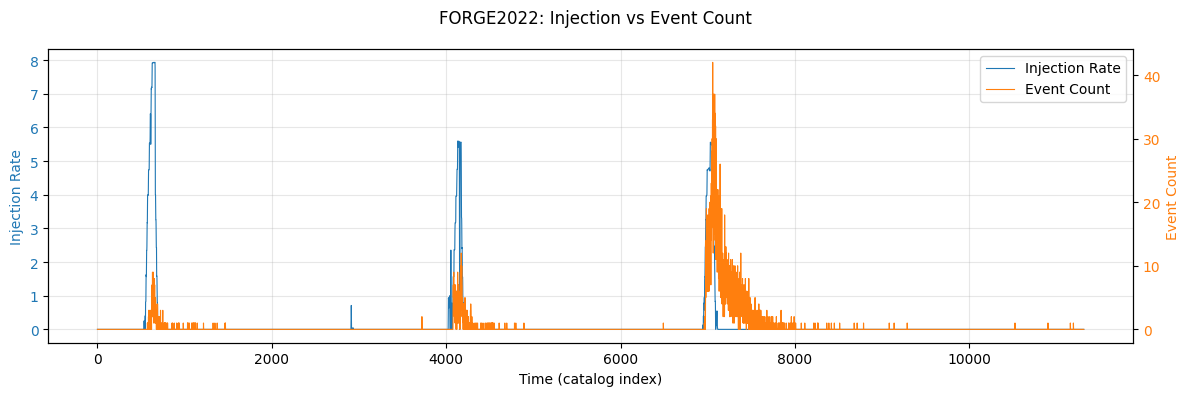

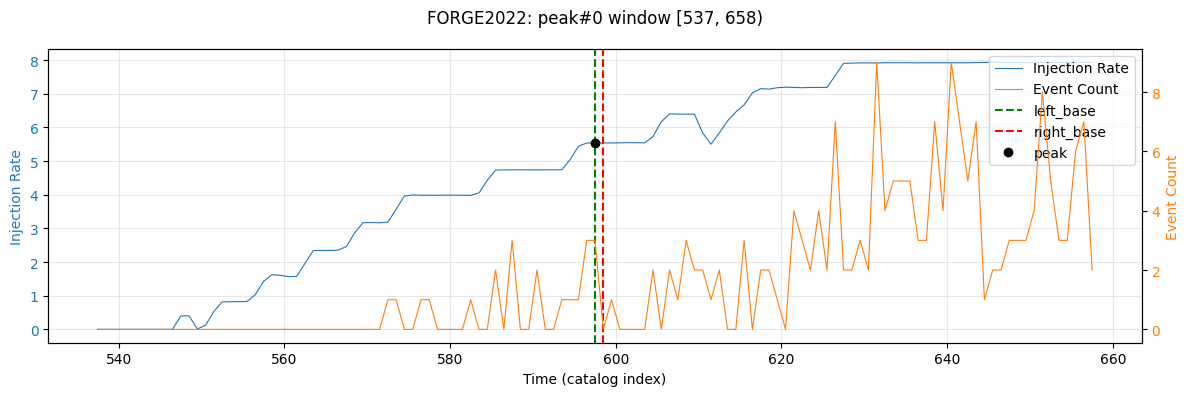

In [6]:
plot_global_overlay(DATASET, series)
plot_peak_window(DATASET, series, peaks, peak_rank=0, offset=60)

## 6) Batch Comparison

In [7]:
DATASETS_TO_COMPARE = [
    'FORGE2022',
    'St1-2020',
    'SSFS1993',
    'CB_HAB1a',
    'CB_HAB4',
    'Basel',
]

compare_df, compare_cache = compare_datasets(
    datasets=DATASETS_TO_COMPARE,
    catalog_cfg=CATALOG_CFG,
    peak_height=PEAK_HEIGHT,
    peak_min_distance=PEAK_MIN_DISTANCE,
)

compare_df

Using registered catalog: FORGE2022-Standard
Using registered catalog: St1-2020-Standard
Using registered catalog: SSFS1993-Standard
Using registered catalog: CB_HAB1a-Standard
Using registered catalog: CB_HAB4-Standard
Using fallback catalog class: InducedTripletBase(Basel)


,dataset,catalog_name,freq,n_events,duration,injection_sum,count_sum,count_to_injection_ratio,n_peaks,mag_completeness
0,CB_HAB1a,CB_HAB1a,1min,20974,6.767600e+04,19505.664062,20974.0,1.075277,227,-1.3
1,CB_HAB4,CB_HAB4,1min,20734,3.426800e+04,36308.414062,20734.0,0.571052,118,-1.3
2,SSFS1993,SSFS1993,5min,10732,1.301180e+04,9186.226562,10732.0,1.168271,65,-1.3
3,FORGE2022,FORGE2022,1min,6060,1.131300e+04,1638.550903,6060.0,3.698390,9,-1.3
4,Basel,Basel,1min,3715,6.144862e+06,11527.287109,3715.0,0.322279,3,-1.3
5,St1-2020,St1-2020,1min,1899,2.049940e+05,2880.829346,1899.0,0.659185,19,-1.3
